In [1]:
# ════════════════════════════════════════════════════════════════════════
# STAGE 0A — Paths & GPU Check
# ════════════════════════════════════════════════════════════════════════
import os, sys, shutil, struct, subprocess
import numpy as np
from pathlib import Path
from PIL import Image as PILImage
import matplotlib.pyplot as plt

os.environ["QT_QPA_PLATFORM"] = "offscreen"

# ── Paths ────────────────────────────────────────────────────────────────
SRC_ROOT    = Path("/kaggle/input/datasets/hadilkarous/hidataset/ignatius")
SRC_SPARSE  = SRC_ROOT / "sparse" / "0"
SRC_IMAGES  = SRC_ROOT / "input"

WORK        = Path("/kaggle/working")
SCENE       = WORK / "scene_clean"          # cleaned scene
UNDIST      = WORK / "scene_undistorted"    # after COLMAP undistortion
OUTPUT_DIR  = WORK / "output_3dgs"          # training output
GS_ROOT     = WORK / "gaussian-splatting"

for d in [SCENE/"sparse/0", SCENE/"images", UNDIST, OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── GPU Check ────────────────────────────────────────────────────────────
print("=" * 60)
print("ENVIRONMENT CHECK")
print("=" * 60)
os.system("nvidia-smi --query-gpu=name,memory.total,driver_version --format=csv,noheader")
print()

# ── Dataset existence check ───────────────────────────────────────────────
print(f"Source root   : {SRC_ROOT.exists()}  →  {SRC_ROOT}")
print(f"Sparse/0      : {SRC_SPARSE.exists()}")
print(f"Input images  : {SRC_IMAGES.exists()}")

if SRC_SPARSE.exists():
    print("\n── COLMAP Binary Files ──")
    for f in sorted(SRC_SPARSE.iterdir()):
        kb = f.stat().st_size / 1024
        print(f"  {f.name:<22} {kb:>10.1f} KB")

if SRC_IMAGES.exists():
    imgs = sorted(SRC_IMAGES.glob("*"))
    print(f"\nTotal source images: {len(imgs)}")

ENVIRONMENT CHECK
Tesla T4, 15360 MiB, 580.105.08
Tesla T4, 15360 MiB, 580.105.08

Source root   : True  →  /kaggle/input/datasets/hadilkarous/hidataset/ignatius
Sparse/0      : True
Input images  : True

── COLMAP Binary Files ──
  cameras.bin                   0.1 KB
  frames.bin                   21.6 KB
  images.bin                62882.1 KB
  points3D.bin              17935.3 KB
  project.ini                   2.2 KB
  rigs.bin                      0.0 KB

Total source images: 263


Analyzing image quality...

── Quality Filter Results ──
  Total images   : 263
  Kept (clean)   : 263
  Rejected blur  : 0
  Rejected exposure: 0

✅ 263 clean images copied to /kaggle/working/scene_clean/images


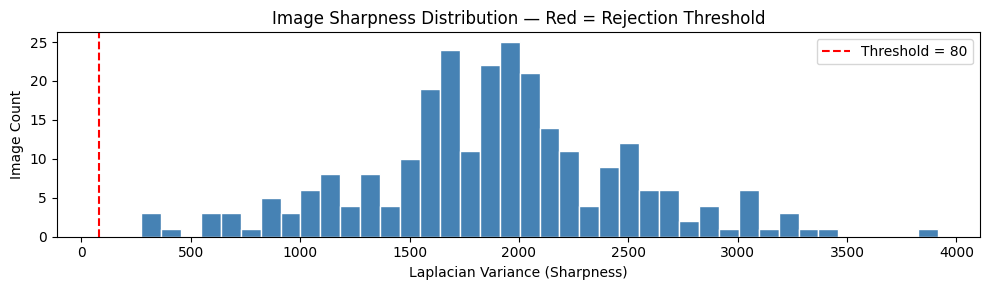

In [2]:
# ════════════════════════════════════════════════════════════════════════
# STAGE 0B — Image Quality Filtering (Blur / Exposure)
# 
# WHY: Blurry or poorly exposed frames corrupt COLMAP feature matching
# and inject noisy gradients during 3DGS training. We use Laplacian
# variance (sharpness) and mean luminance to reject bad frames.
#
# THRESHOLDS (tuned for 1920×1080 statue footage):
#   blur_thresh  = 80   → Laplacian variance; below = blurry
#   dark_thresh  = 20   → mean pixel value 0-255; below = underexposed
#   bright_thresh= 240  → mean pixel value 0-255; above = overexposed
# ════════════════════════════════════════════════════════════════════════
import cv2

BLUR_THRESH   = 80
DARK_THRESH   = 20
BRIGHT_THRESH = 240

src_images  = sorted(SRC_IMAGES.glob("*"))
dst_images  = SCENE / "images"

kept, rejected_blur, rejected_exposure = [], [], []

print("Analyzing image quality...")
blur_scores = []

for img_path in src_images:
    if img_path.suffix.lower() not in (".jpg", ".jpeg", ".png"):
        continue
    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None:
        continue
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blur  = cv2.Laplacian(gray, cv2.CV_64F).var()
    mean_lum = gray.mean()
    blur_scores.append((img_path.name, blur, mean_lum))

    if blur < BLUR_THRESH:
        rejected_blur.append(img_path.name)
    elif mean_lum < DARK_THRESH or mean_lum > BRIGHT_THRESH:
        rejected_exposure.append(img_path.name)
    else:
        kept.append(img_path)

print(f"\n── Quality Filter Results ──")
print(f"  Total images   : {len(src_images)}")
print(f"  Kept (clean)   : {len(kept)}")
print(f"  Rejected blur  : {len(rejected_blur)}")
print(f"  Rejected exposure: {len(rejected_exposure)}")

# Safety: if we're removing >20% of images, warn and relax thresholds
rejection_rate = (len(rejected_blur) + len(rejected_exposure)) / max(len(src_images), 1)
if rejection_rate > 0.20:
    print(f"\n⚠️  High rejection rate ({rejection_rate:.0%}). Relaxing blur threshold to 50.")
    BLUR_THRESH = 50
    kept, rejected_blur, rejected_exposure = [], [], []
    for img_path, blur, mean_lum in [(p, b, l) for p, b, l in
                                     [(src_images[i], *blur_scores[i][1:]) 
                                      for i in range(len(blur_scores))]]:
        if blur < BLUR_THRESH:
            rejected_blur.append(img_path.name)
        elif mean_lum < DARK_THRESH or mean_lum > BRIGHT_THRESH:
            rejected_exposure.append(img_path.name)
        else:
            kept.append(img_path)
    print(f"  After relaxing — Kept: {len(kept)} | Rejected: {len(rejected_blur)+len(rejected_exposure)}")

# Copy good images to working scene
for img_path in kept:
    shutil.copy2(img_path, dst_images / img_path.name)

print(f"\n✅ {len(kept)} clean images copied to {dst_images}")

# Plot blur score distribution
scores = [b for _, b, _ in blur_scores]
plt.figure(figsize=(10, 3))
plt.hist(scores, bins=40, color='steelblue', edgecolor='white')
plt.axvline(BLUR_THRESH, color='red', linestyle='--', label=f'Threshold = {BLUR_THRESH}')
plt.xlabel('Laplacian Variance (Sharpness)')
plt.ylabel('Image Count')
plt.title('Image Sharpness Distribution — Red = Rejection Threshold')
plt.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/blur_distribution.png", dpi=120)
plt.show()

In [3]:
# ════════════════════════════════════════════════════════════════════════
# STAGE 1A — Parse COLMAP images.bin to get per-image observation counts
# 
# COLMAP images.bin format (binary):
#   uint64 num_images
#   for each image:
#     uint32 image_id
#     double[4] qvec (quaternion rotation)
#     double[3] tvec (translation)
#     uint32 camera_id
#     char[] name (null-terminated)
#     uint64 num_points2D
#     for each point2D:
#       double x, double y, uint64 point3D_id
# ════════════════════════════════════════════════════════════════════════

def parse_images_bin(path):
    """Returns dict: image_name -> {id, qvec, tvec, cam_id, n_obs, n_valid_obs}"""
    images = {}
    with open(path, 'rb') as f:
        num_imgs = struct.unpack('<Q', f.read(8))[0]
        for _ in range(num_imgs):
            img_id  = struct.unpack('<I', f.read(4))[0]
            qvec    = struct.unpack('<4d', f.read(32))  # quaternion
            tvec    = struct.unpack('<3d', f.read(24))  # translation
            cam_id  = struct.unpack('<I', f.read(4))[0]
            # Read null-terminated name
            name = b''
            while True:
                c = f.read(1)
                if c == b'\x00': break
                name += c
            name = name.decode('utf-8')
            # Read 2D points
            num_pts = struct.unpack('<Q', f.read(8))[0]
            valid_obs = 0
            for _ in range(num_pts):
                x, y = struct.unpack('<2d', f.read(16))
                p3d_id = struct.unpack('<q', f.read(8))[0]  # signed
                if p3d_id != -1:
                    valid_obs += 1
            images[name] = {
                'id': img_id,
                'qvec': np.array(qvec),
                'tvec': np.array(tvec),
                'cam_id': cam_id,
                'n_total_obs': num_pts,
                'n_valid_obs': valid_obs
            }
    return images


def parse_points3D_bin(path):
    """Returns array of reprojection errors per point."""
    errors = []
    with open(path, 'rb') as f:
        num_pts = struct.unpack('<Q', f.read(8))[0]
        for _ in range(num_pts):
            pt_id  = struct.unpack('<Q', f.read(8))[0]
            xyz    = struct.unpack('<3d', f.read(24))
            rgb    = struct.unpack('<3B', f.read(3))
            error  = struct.unpack('<d', f.read(8))[0]
            errors.append(error)
            # Track: uint64 num_tracks, then track elements
            track_len = struct.unpack('<Q', f.read(8))[0]
            f.read(track_len * 8)  # img_id(4) + point2D_idx(4) per track
    return np.array(errors)


print("Parsing COLMAP binary files...")
colmap_images = parse_images_bin(SRC_SPARSE / "images.bin")
reproj_errors = parse_points3D_bin(SRC_SPARSE / "points3D.bin")

print(f"\n── COLMAP Model Stats ──")
print(f"  Registered images      : {len(colmap_images)}")
print(f"  Total 3D points        : {len(reproj_errors):,}")
print(f"  Median reprojection err: {np.median(reproj_errors):.3f} px")
print(f"  Mean reprojection err  : {np.mean(reproj_errors):.3f} px")
print(f"  95th pctile reproj err : {np.percentile(reproj_errors, 95):.3f} px")

# Observation count per image
obs_counts = {name: d['n_valid_obs'] for name, d in colmap_images.items()}
obs_vals   = list(obs_counts.values())
print(f"\n── Per-Image Valid 3D Observations ──")
print(f"  Min obs : {min(obs_vals)}")
print(f"  Median  : {int(np.median(obs_vals))}")
print(f"  Max obs : {max(obs_vals)}")

import matplotlib
matplotlib.use('Agg')  # non-interactive backend — never hangs on Kaggle
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.hist(reproj_errors[reproj_errors < 5], bins=60, color='steelblue', edgecolor='white')
ax1.axvline(1.5, color='orange', linestyle='--', label='1.5 px warn')
ax1.axvline(2.0, color='red',    linestyle='--', label='2.0 px reject')
ax1.set_xlabel('Reprojection Error (px)')
ax1.set_ylabel('Point Count')
ax1.set_title('3D Point Reprojection Errors')
ax1.legend()

ax2.hist(obs_vals, bins=40, color='coral', edgecolor='white')
ax2.axvline(500, color='red', linestyle='--', label='500 obs threshold')
ax2.set_xlabel('Valid 3D Observations per Image')
ax2.set_ylabel('Image Count')
ax2.set_title('Per-Image Observation Count')
ax2.legend()

plt.tight_layout()
plt.savefig("/kaggle/working/colmap_analysis.png", dpi=100, bbox_inches='tight')
plt.close(fig)  # release memory immediately
print("✅ Plot saved to colmap_analysis.png")

Parsing COLMAP binary files...

── COLMAP Model Stats ──
  Registered images      : 263
  Total 3D points        : 159,469
  Median reprojection err: 0.893 px
  Mean reprojection err  : 0.948 px
  95th pctile reproj err : 1.807 px

── Per-Image Valid 3D Observations ──
  Min obs : 1956
  Median  : 4754
  Max obs : 7991
✅ Plot saved to colmap_analysis.png


In [4]:
# ════════════════════════════════════════════════════════════════════════
# STAGE 1B — Filter weakly-localized images
#
# An image with <500 valid 3D observations has high pose uncertainty.
# Including it in training injects noisy viewpoint gradients and hurts
# convergence. We cross-reference the COLMAP registered set with our
# quality-passed image set from Stage 0.
# ════════════════════════════════════════════════════════════════════════

OBS_THRESHOLD = 500  # minimum 3D observations for a frame to be trusted

# Images that passed Stage 0 quality filter
quality_passed = set(f.name for f in dst_images.glob("*"))

# Images registered in COLMAP with enough observations
well_localized  = {name for name, d in colmap_images.items() 
                   if d['n_valid_obs'] >= OBS_THRESHOLD}
poorly_localized = {name for name, d in colmap_images.items()
                    if d['n_valid_obs'] < OBS_THRESHOLD}
not_in_colmap   = quality_passed - set(colmap_images.keys())

# Final accepted set
accepted = quality_passed & well_localized

print("── Image Filtering Summary ──")
print(f"  After Stage 0 (quality) : {len(quality_passed)}")
print(f"  In COLMAP & well-local. : {len(well_localized)}")
print(f"  Poorly localized (<{OBS_THRESHOLD}): {len(poorly_localized)}")
print(f"  Not in COLMAP at all    : {len(not_in_colmap)}")
print(f"  ✅ Final accepted set    : {len(accepted)}")

if poorly_localized:
    print(f"\n  Poorly localized frames (first 10):")
    for name in sorted(poorly_localized)[:10]:
        print(f"    {name}  ({colmap_images[name]['n_valid_obs']} obs)")

# Remove rejected images from working scene/images folder
removed = 0
for img_file in list(dst_images.glob("*")):
    if img_file.name not in accepted:
        img_file.unlink()
        removed += 1

print(f"\n  Removed {removed} images from working scene.")
print(f"  Final image count in scene/images: {len(list(dst_images.glob('*')))}")

── Image Filtering Summary ──
  After Stage 0 (quality) : 263
  In COLMAP & well-local. : 263
  Poorly localized (<500): 0
  Not in COLMAP at all    : 0
  ✅ Final accepted set    : 263

  Removed 0 images from working scene.
  Final image count in scene/images: 263


In [5]:
# ════════════════════════════════════════════════════════════════════════
# STAGE 2 — Angular Coverage-Based Train/Test Split
#
# We use camera center positions (derived from -R^T @ t) in the XZ plane
# (azimuth angle) to ensure test views are angularly spread.
#
# Strategy: divide the orbit into N_TEST equal angular sectors, pick
# the frame closest to each sector center as a test view.
# ════════════════════════════════════════════════════════════════════════

def qvec_to_rotation(qvec):
    """COLMAP quaternion (w,x,y,z) to 3×3 rotation matrix."""
    w, x, y, z = qvec
    return np.array([
        [1-2*(y*y+z*z), 2*(x*y-w*z),   2*(x*z+w*y)],
        [2*(x*y+w*z),   1-2*(x*x+z*z), 2*(y*z-w*x)],
        [2*(x*z-w*y),   2*(y*z+w*x),   1-2*(x*x+y*y)]
    ])

def camera_center(qvec, tvec):
    """World-space camera position: C = -R^T @ t"""
    R = qvec_to_rotation(qvec)
    return -R.T @ np.array(tvec)


# Build per-accepted-image info
img_info = []
for name in sorted(accepted):
    if name not in colmap_images:
        continue
    d = colmap_images[name]
    C = camera_center(d['qvec'], d['tvec'])
    azimuth = np.degrees(np.arctan2(C[0], C[2]))  # XZ plane angle
    img_info.append({'name': name, 'center': C, 'azimuth': azimuth})

img_info.sort(key=lambda x: x['azimuth'])
n_total = len(img_info)

# How many test views?
N_TEST = max(1, n_total // 8)  # ~12.5% test, same ratio as llff-hold=8
print(f"Total accepted images : {n_total}")
print(f"Target test views     : {N_TEST}")

# Divide orbit into N_TEST sectors, pick best from each
sector_size = 360.0 / N_TEST
test_names  = set()

for s in range(N_TEST):
    sector_center = -180 + s * sector_size + sector_size / 2
    # Wrap-around angle difference
    def ang_diff(a, b):
        d = abs(a - b) % 360
        return d if d <= 180 else 360 - d
    best = min(img_info, key=lambda x: ang_diff(x['azimuth'], sector_center))
    test_names.add(best['name'])

train_names = set(x['name'] for x in img_info) - test_names

print(f"\n── Angular Split Result ──")
print(f"  Train  : {len(train_names)}")
print(f"  Test   : {len(test_names)}")
print(f"  Test % : {100*len(test_names)/n_total:.1f}%")

# Visualize the split on a polar plot
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(6, 6))

for info in img_info:
    az_rad = np.radians(info['azimuth'])
    r = np.linalg.norm(info['center'][[0,2]])  # XZ radius
    color = 'red' if info['name'] in test_names else 'steelblue'
    ax.scatter(az_rad, r, c=color, s=25, zorder=3)

ax.set_title('Camera Positions (Top View)\nBlue=Train  Red=Test', pad=20)
plt.tight_layout()
plt.savefig("/kaggle/working/camera_split.png", dpi=120)
plt.show()

# Save split lists for reference
with open(WORK / "train_list.txt", 'w') as f:
    f.write('\n'.join(sorted(train_names)))
with open(WORK / "test_list.txt", 'w') as f:
    f.write('\n'.join(sorted(test_names)))
print("\n✅ Split saved to train_list.txt and test_list.txt")

Total accepted images : 263
Target test views     : 32

── Angular Split Result ──
  Train  : 231
  Test   : 32
  Test % : 12.2%

✅ Split saved to train_list.txt and test_list.txt


In [6]:
# ════════════════════════════════════════════════════════════════════════
# STAGE 3A — Copy COLMAP sparse files to working scene
# ════════════════════════════════════════════════════════════════════════

dst_sparse = SCENE / "sparse" / "0"
required_bins = ["cameras.bin", "images.bin", "points3D.bin"]

print("Copying COLMAP sparse files...")
for fname in required_bins:
    src = SRC_SPARSE / fname
    if src.exists():
        shutil.copy2(src, dst_sparse / fname)
        kb = src.stat().st_size / 1024
        print(f"  ✅ {fname}  ({kb:.0f} KB)")
    else:
        print(f"  ❌ MISSING: {fname}")

print(f"\n  Images in scene/images/ : {len(list((SCENE/'images').glob('*')))}")

Copying COLMAP sparse files...
  ✅ cameras.bin  (0 KB)
  ✅ images.bin  (62882 KB)
  ✅ points3D.bin  (17935 KB)

  Images in scene/images/ : 263


In [7]:
# ════════════════════════════════════════════════════════════════════════
# STAGE 3B — Install COLMAP and run image_undistorter
#
# WHY UNDISTORT: 3DGS assumes pinhole cameras. If COLMAP used OPENCV or
# RADIAL models, there is lens distortion baked into the images. Running
# image_undistorter removes it and updates camera params to pure pinhole.
# Skipping this causes soft reconstructions near frame edges.
# ════════════════════════════════════════════════════════════════════════

os.system("apt-get update -qq && apt-get install -y -qq colmap")

undist_cmd = [
    "colmap", "image_undistorter",
    "--image_path",  str(SCENE / "images"),
    "--input_path",  str(SCENE / "sparse" / "0"),
    "--output_path", str(UNDIST),
    "--output_type", "COLMAP",
]

print("Running COLMAP image_undistorter...")
result = subprocess.run(undist_cmd, capture_output=True, text=True)

if result.returncode == 0:
    print("✅ Undistortion complete")
else:
    print("❌ Undistorter error:")
    print(result.stderr[-2000:])

# Fix folder structure: COLMAP may output sparse/ instead of sparse/0/
undist_sparse0 = UNDIST / "sparse" / "0"
if not undist_sparse0.exists():
    print("Fixing sparse folder structure...")
    undist_sparse0.mkdir(parents=True, exist_ok=True)
    for fname in required_bins:
        src_f = UNDIST / "sparse" / fname
        if src_f.exists():
            src_f.rename(undist_sparse0 / fname)
            print(f"  Moved {fname} → sparse/0/")

# Validate output
print("\n── Undistorted Scene Contents ──")
for d in [UNDIST/"sparse/0", UNDIST/"images"]:
    if d.exists():
        count = len(list(d.iterdir()))
        print(f"  {d.relative_to(WORK)} : {count} files")
    else:
        print(f"  ⚠️  Missing: {d}")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


Selecting previously unselected package libdouble-conversion3:amd64.
(Reading database ... 124626 files and directories currently installed.)
Preparing to unpack .../00-libdouble-conversion3_3.1.7-4_amd64.deb ...
Unpacking libdouble-conversion3:amd64 (3.1.7-4) ...
Selecting previously unselected package libqt5core5a:amd64.
Preparing to unpack .../01-libqt5core5a_5.15.3+dfsg-2ubuntu0.2_amd64.deb ...
Unpacking libqt5core5a:amd64 (5.15.3+dfsg-2ubuntu0.2) ...
Selecting previously unselected package libevdev2:amd64.
Preparing to unpack .../02-libevdev2_1.12.1+dfsg-1_amd64.deb ...
Unpacking libevdev2:amd64 (1.12.1+dfsg-1) ...
Selecting previously unselected package libmtdev1:amd64.
Preparing to unpack .../03-libmtdev1_1.1.6-1build4_amd64.deb ...
Unpacking libmtdev1:amd64 (1.1.6-1build4) ...
Selecting previously unselected package libgudev-1.0-0:amd64.
Preparing to unpack .../04-libgudev-1.0-0_1%3a237-2build1_amd64.deb ...
Unpacking libgudev-1.0-0:amd64 (1:237-2build1) ...
Selecting previousl

In [8]:
# ════════════════════════════════════════════════════════════════════════
# STAGE 4A — Clone & Build Gaussian Splatting
# ════════════════════════════════════════════════════════════════════════

if not GS_ROOT.exists():
    print("Cloning Gaussian Splatting repo...")
    subprocess.run([
        "git", "clone", "--recursive",
        "https://github.com/graphdeco-inria/gaussian-splatting",
        str(GS_ROOT)
    ], check=True)
    print("✅ Cloned")
else:
    print("✅ Repo already present")

print("Installing CUDA extensions (takes ~3-5 min)...")
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                str(GS_ROOT / "submodules/diff-gaussian-rasterization")], check=True)
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                str(GS_ROOT / "submodules/simple-knn")], check=True)
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "plyfile", "tqdm", "lpips"], check=True)
print("✅ All dependencies installed")

Cloning Gaussian Splatting repo...


Cloning into '/kaggle/working/gaussian-splatting'...
Submodule 'SIBR_viewers' (https://gitlab.inria.fr/sibr/sibr_core.git) registered for path 'SIBR_viewers'
Submodule 'submodules/diff-gaussian-rasterization' (https://github.com/graphdeco-inria/diff-gaussian-rasterization.git) registered for path 'submodules/diff-gaussian-rasterization'
Submodule 'submodules/fused-ssim' (https://github.com/rahul-goel/fused-ssim.git) registered for path 'submodules/fused-ssim'
Submodule 'submodules/simple-knn' (https://gitlab.inria.fr/bkerbl/simple-knn.git) registered for path 'submodules/simple-knn'
Cloning into '/kaggle/working/gaussian-splatting/SIBR_viewers'...
Cloning into '/kaggle/working/gaussian-splatting/submodules/diff-gaussian-rasterization'...
Cloning into '/kaggle/working/gaussian-splatting/submodules/fused-ssim'...
Cloning into '/kaggle/working/gaussian-splatting/submodules/simple-knn'...


Submodule path 'SIBR_viewers': checked out 'd8856f60c5384cc1975439193bb627d77d917d77'
Submodule path 'submodules/diff-gaussian-rasterization': checked out '9c5c2028f6fbee2be239bc4c9421ff894fe4fbe0'


Submodule 'third_party/glm' (https://github.com/g-truc/glm.git) registered for path 'submodules/diff-gaussian-rasterization/third_party/glm'
Cloning into '/kaggle/working/gaussian-splatting/submodules/diff-gaussian-rasterization/third_party/glm'...


Submodule path 'submodules/diff-gaussian-rasterization/third_party/glm': checked out '5c46b9c07008ae65cb81ab79cd677ecc1934b903'
Submodule path 'submodules/fused-ssim': checked out '1272e21a282342e89537159e4bad508b19b34157'
Submodule path 'submodules/simple-knn': checked out '86710c2d4b46680c02301765dd79e465819c8f19'
✅ Cloned
Installing CUDA extensions (takes ~3-5 min)...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.2 MB/s eta 0:00:00
✅ All dependencies installed


In [9]:
import os, sys, subprocess
from pathlib import Path

os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

# Clear stale output
import shutil
shutil.rmtree("/kaggle/working/output_3dgs", ignore_errors=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("✅ Output dir cleared")

DATASET_PATH = str(UNDIST)
GS_ROOT      = Path("/kaggle/working/gaussian-splatting")

train_args = [
    sys.executable, str(GS_ROOT / "train.py"),
    "-s",  DATASET_PATH,
    "-m",  str(OUTPUT_DIR),

    # ── Densification (OOM-safe) ────────────────────────────────────
    "--densify_grad_threshold",    "0.00025",
    "--densify_until_iter",        "20000",
    "--densify_from_iter",         "500",
    "--densification_interval",    "100",
    "--opacity_reset_interval",    "3000",
    "--percent_dense",             "0.01",   # back to default — 0.005 caused OOM

    # ── Learning rates ──────────────────────────────────────────────
    "--position_lr_init",          "0.00016",
    "--position_lr_final",         "0.0000016",
    "--position_lr_delay_mult",    "0.01",
    "--position_lr_max_steps",     "30000",

    # ── Training ────────────────────────────────────────────────────
    "--iterations",                "30000",
    "--resolution",                "1",
    "--random_background",
    "--eval",
    "--disable_viewer",

    # ── Saves ───────────────────────────────────────────────────────
    "--save_iterations",       "15000", "30000",
    "--test_iterations",       "7000", "15000", "30000",
    "--checkpoint_iterations", "15000", "30000",
]

print("🚀 Starting Training...")
print(f"   PYTORCH_ALLOC_CONF = expandable_segments:True")
print(f"   densify_grad_threshold = 0.00025")
print(f"   percent_dense = 0.01 (default)")
print()

result = subprocess.run(train_args, cwd=str(GS_ROOT))

if result.returncode == 0:
    print("\n✅ Training completed!")
else:
    print(f"\n❌ Failed with code {result.returncode}")
   

✅ Output dir cleared
🚀 Starting Training...
   PYTORCH_ALLOC_CONF = expandable_segments:True
   densify_grad_threshold = 0.00025
   percent_dense = 0.01 (default)



2026-04-29 13:54:01.772053: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777470841.986136    1699 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777470842.049275    1699 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777470842.576344    1699 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777470842.576391    1699 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777470842.576394    1699 computation_placer.cc:177] computation placer alr

Optimizing /kaggle/working/output_3dgs
Output folder: /kaggle/working/output_3dgs [29/04 13:54:24]
------------LLFF HOLD------------- [29/04 13:54:25]
Reading camera 263/263 [29/04 13:54:25]
Converting point3d.bin to .ply, will happen only the first time you open the scene. [29/04 13:54:25]
Loading Training Cameras [29/04 13:54:26]
Loading Test Cameras [29/04 13:54:40]
Number of points at initialisation :  159469 [29/04 13:54:42]


Training progress: 100%|██████████| 30000/30000 [2:17:19<00:00,  3.64it/s, Loss=0.0720926, Depth Loss=0.0000000]



[ITER 7000] Evaluating test: L1 0.07187984499967459 PSNR 20.057368220704976 [29/04 14:20:12]

[ITER 7000] Evaluating train: L1 0.053305224329233174 PSNR 21.934763336181643 [29/04 14:20:25]

[ITER 15000] Evaluating test: L1 0.06822149037863269 PSNR 20.582717201926492 [29/04 14:57:43]

[ITER 15000] Evaluating train: L1 0.0414538785815239 PSNR 23.831016540527344 [29/04 14:57:49]

[ITER 15000] Saving Gaussians [29/04 14:57:50]

[ITER 15000] Saving Checkpoint [29/04 14:58:07]

[ITER 30000] Evaluating test: L1 0.06573683237939171 PSNR 21.069108645121258 [29/04 16:12:15]

[ITER 30000] Evaluating train: L1 0.03651128187775612 PSNR 24.74851303100586 [29/04 16:12:22]

[ITER 30000] Saving Gaussians [29/04 16:12:22]

[ITER 30000] Saving Checkpoint [29/04 16:12:40]

Training complete. [29/04 16:12:42]

✅ Training completed!


In [10]:
# ════════════════════════════════════════════════════════════════════════
# STAGE 5A — Run Official render.py + metrics.py
# ════════════════════════════════════════════════════════════════════════

RENDER_SCRIPT  = GS_ROOT / "render.py"
METRICS_SCRIPT = GS_ROOT / "metrics.py"

for checkpoint_iter in ["30000"]:
    print(f"\n{'='*50}")
    print(f"Rendering checkpoint @ iter {checkpoint_iter}...")
    print(f"{'='*50}")
    
    render_args = [
        sys.executable, str(RENDER_SCRIPT),
        "-m", str(OUTPUT_DIR),
        "--iteration", checkpoint_iter,
        "--skip_train",  # only render test views to save time
        "--quiet",
    ]
    r = subprocess.run(render_args, cwd=str(GS_ROOT))
    if r.returncode != 0:
        print(f"  ❌ Render failed")
        continue
    print(f"  ✅ Render done")
    
    metrics_args = [
        sys.executable, str(METRICS_SCRIPT),
        "-m", str(OUTPUT_DIR),
    ]
    r = subprocess.run(metrics_args, cwd=str(GS_ROOT))
    if r.returncode != 0:
        print(f"  ❌ Metrics failed")
    else:
        print(f"  ✅ Metrics computed")


Rendering checkpoint @ iter 30000...
Looking for config file in /kaggle/working/output_3dgs/cfg_args
Config file found: /kaggle/working/output_3dgs/cfg_args
Rendering /kaggle/working/output_3dgs


Rendering progress: 100%|██████████| 33/33 [00:56<00:00,  1.71s/it]


  ✅ Render done

Scene: /kaggle/working/output_3dgs
Method: ours_30000


Metric evaluation progress:   0%|          | 0/33 [00:00<?, ?it/s]

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth



  0%|          | 0.00/528M [00:00<?, ?B/s]
  2%|▏         | 9.38M/528M [00:00<00:05, 98.0MB/s]
  6%|▋         | 33.1M/528M [00:00<00:02, 186MB/s] 
 11%|█         | 56.9M/528M [00:00<00:02, 215MB/s]
 15%|█▍        | 79.0M/528M [00:00<00:02, 221MB/s]
 19%|█▉        | 102M/528M [00:00<00:01, 229MB/s] 
 24%|██▍       | 125M/528M [00:00<00:01, 234MB/s]
 28%|██▊       | 148M/528M [00:00<00:01, 232MB/s]
 32%|███▏      | 170M/528M [00:00<00:01, 233MB/s]
 37%|███▋      | 194M/528M [00:00<00:01, 238MB/s]
 41%|████▏     | 218M/528M [00:01<00:01, 242MB/s]
 46%|████▌     | 241M/528M [00:01<00:01, 243MB/s]
 50%|█████     | 265M/528M [00:01<00:01, 244MB/s]
 55%|█████▍    | 288M/528M [00:01<00:01, 242MB/s]
 59%|█████▉    | 312M/528M [00:01<00:00, 242MB/s]
 63%|██████▎   | 335M/528M [00:01<00:00, 243MB/s]
 68%|██████▊   | 358M/528M [00:01<00:00, 244MB/s]
 72%|███████▏  | 382M/528M [00:01<00:00, 245MB/s]
 77%|███████▋  | 405M/528M [00:01<00:00, 244MB/s]
 81%|████████▏ | 429M/528M [00:01<00:00, 246MB/s]

Downloading: "https://raw.githubusercontent.com/richzhang/PerceptualSimilarity/master/lpips/weights/v0.1/vgg.pth" to /root/.cache/torch/hub/checkpoints/vgg.pth



100%|██████████| 7.12k/7.12k [00:00<00:00, 16.1MB/s]
Metric evaluation progress: 100%|██████████| 33/33 [01:08<00:00,  2.07s/it]


  SSIM :    0.7197174
  PSNR :   21.0530739
  LPIPS:    0.2913924

  ✅ Metrics computed


In [11]:
# ════════════════════════════════════════════════════════════════════════
# STAGE 5B — Parse and Display Results
# ════════════════════════════════════════════════════════════════════════
import json

def parse_results_json(model_dir):
    """Parse results.json files output by metrics.py"""
    results = {}
    for results_file in sorted(Path(model_dir).glob("**/results.json")):
        try:
            with open(results_file) as f:
                data = json.load(f)
            results[results_file] = data
        except Exception as e:
            print(f"  Could not parse {results_file}: {e}")
    return results

all_results = parse_results_json(OUTPUT_DIR)

if not all_results:
    # Fallback: look for per-image metric logs if results.json is missing
    print("No results.json found. Checking for log files...")
    for logf in sorted(Path(OUTPUT_DIR).rglob("*.txt")):
        print(f"  {logf}")
else:
    print("\n" + "═" * 60)
    print("EVALUATION RESULTS")
    print("═" * 60)
    for path, data in sorted(all_results.items()):
        print(f"\n  File: {path.relative_to(OUTPUT_DIR)}")
        for split, metrics in data.items():
            print(f"  [{split}]")
            if isinstance(metrics, dict):
                for k, v in metrics.items():
                    print(f"    {k:<15}: {v:.4f}" if isinstance(v, float) else f"    {k}: {v}")

# Also print from training log if available
train_log = OUTPUT_DIR / "train_log.txt"
if not train_log.exists():
    # Check for any log
    logs = list(OUTPUT_DIR.glob("*.txt")) + list(OUTPUT_DIR.glob("*.log"))
    if logs:
        print("\n── Training Log Tail ──")
        os.system(f"tail -30 {logs[0]}")


════════════════════════════════════════════════════════════
EVALUATION RESULTS
════════════════════════════════════════════════════════════

  File: results.json
  [ours_30000]
    SSIM           : 0.7197
    PSNR           : 21.0531
    LPIPS          : 0.2914


In [12]:
# ════════════════════════════════════════════════════════════════════════
# STAGE 5C — Per-Image PSNR Breakdown
#
# We compute per-image PSNR manually over the rendered test views
# to identify which viewpoints are hardest and flag outliers.
# ════════════════════════════════════════════════════════════════════════
import torch

def psnr(img1, img2):
    """img1, img2: numpy arrays HxWx3 in [0,255]"""
    mse = np.mean((img1.astype(np.float32) - img2.astype(np.float32)) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(255.0 / np.sqrt(mse))

# Find rendered outputs
render_gt_dir  = OUTPUT_DIR / "test" / "ours_30000" / "gt"
render_out_dir = OUTPUT_DIR / "test" / "ours_30000" / "renders"

if render_gt_dir.exists() and render_out_dir.exists():
    gt_files     = sorted(render_gt_dir.glob("*.png")) + sorted(render_gt_dir.glob("*.jpg"))
    render_files = sorted(render_out_dir.glob("*.png")) + sorted(render_out_dir.glob("*.jpg"))
    
    per_img_psnr = []
    for gt_f, rd_f in zip(gt_files, render_files):
        gt  = np.array(PILImage.open(gt_f).convert("RGB"))
        rd  = np.array(PILImage.open(rd_f).convert("RGB"))
        if gt.shape != rd.shape:
            rd = np.array(PILImage.fromarray(rd).resize((gt.shape[1], gt.shape[0])))
        p = psnr(gt, rd)
        per_img_psnr.append((gt_f.name, p))
    
    per_img_psnr.sort(key=lambda x: x[1])
    psnr_vals = [p for _, p in per_img_psnr]
    
    print("\n═" * 60)
    print("PER-IMAGE PSNR BREAKDOWN (Test Set)")
    print("═" * 60)
    print(f"  Mean PSNR   : {np.mean(psnr_vals):.2f} dB")
    print(f"  Median PSNR : {np.median(psnr_vals):.2f} dB")
    print(f"  Min PSNR    : {min(psnr_vals):.2f} dB  ({per_img_psnr[0][0]})")
    print(f"  Max PSNR    : {max(psnr_vals):.2f} dB  ({per_img_psnr[-1][0]})")
    print(f"  Std Dev     : {np.std(psnr_vals):.2f} dB")

    print("\n  5 Hardest Views (lowest PSNR):")
    for name, p in per_img_psnr[:5]:
        flag = " ← investigate" if p < np.mean(psnr_vals) - 2 * np.std(psnr_vals) else ""
        print(f"    {name}  {p:.2f} dB{flag}")

    # Plot per-image PSNR
    plt.figure(figsize=(12, 4))
    plt.bar(range(len(psnr_vals)), psnr_vals, color='steelblue', edgecolor='none')
    plt.axhline(np.mean(psnr_vals), color='red', linestyle='--', label=f'Mean = {np.mean(psnr_vals):.2f} dB')
    plt.xlabel('Test Image (sorted by PSNR)')
    plt.ylabel('PSNR (dB)')
    plt.title('Per-Image PSNR — Test Set @ 30k Iterations')
    plt.legend()
    plt.tight_layout()
    plt.savefig("/kaggle/working/per_image_psnr.png", dpi=120)
    plt.show()
else:
    print(f"⚠️  Rendered test outputs not found at expected path:")
    print(f"   GT     : {render_gt_dir}")
    print(f"   Renders: {render_out_dir}")
    print("   Check training completed successfully.")


═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
PER-IMAGE PSNR BREAKDOWN (Test Set)
════════════════════════════════════════════════════════════
  Mean PSNR   : 21.05 dB
  Median PSNR : 21.69 dB
  Min PSNR    : 12.07 dB  (00024.png)
  Max PSNR    : 24.11 dB  (00012.png)
  Std Dev     : 2.23 dB

  5 Hardest Views (lowest PSNR):
    00024.png  12.07 dB ← investigate
    00020.png  17.37 dB
    00032.png  18.49 dB
    00011.png  18.85 dB
    00017.png  19.28 dB


In [13]:
# ════════════════════════════════════════════════════════════════════════
# STAGE 5D — Visual Side-by-Side Comparison (GT vs Rendered)
# ════════════════════════════════════════════════════════════════════════

if render_gt_dir.exists() and render_out_dir.exists():
    gt_files     = sorted(render_gt_dir.glob("*.png")) + sorted(render_gt_dir.glob("*.jpg"))
    render_files = sorted(render_out_dir.glob("*.png")) + sorted(render_out_dir.glob("*.jpg"))
    
    # Show 6 comparisons: worst 3 and best 3
    show_pairs = per_img_psnr[:3] + per_img_psnr[-3:]
    labels = [f"WORST {i+1}" for i in range(3)] + [f"BEST {i+1}" for i in range(3)]
    
    fig, axes = plt.subplots(2, 6, figsize=(20, 7))
    
    for col, ((name, p), label) in enumerate(zip(show_pairs, labels)):
        gt_path = render_gt_dir / name
        rd_path = render_out_dir / name
        if not gt_path.exists() or not rd_path.exists():
            continue
        gt_img = np.array(PILImage.open(gt_path).convert("RGB"))
        rd_img = np.array(PILImage.open(rd_path).convert("RGB"))
        
        axes[0, col].imshow(gt_img)
        axes[0, col].set_title(f"{label}\nGT: {name[:12]}", fontsize=7)
        axes[0, col].axis('off')
        
        axes[1, col].imshow(rd_img)
        axes[1, col].set_title(f"Rendered\nPSNR: {p:.2f} dB", fontsize=7)
        axes[1, col].axis('off')
    
    plt.suptitle("GT (top) vs Rendered (bottom) — Worst 3 + Best 3", fontsize=12)
    plt.tight_layout()
    plt.savefig("/kaggle/working/comparison_grid.png", dpi=100)
    plt.show()

In [14]:
# ════════════════════════════════════════════════════════════════════════
# STAGE 6A — Full Pipeline Summary
# ════════════════════════════════════════════════════════════════════════

print("\n" + "═" * 60)
print("FULL PIPELINE SUMMARY")
print("═" * 60)

# Images
n_final_train = len(train_names)
n_final_test  = len(test_names)
print(f"\n  Dataset:")
print(f"    Original images          : {len(src_images)}")
print(f"    After quality filter      : {len(kept)}")
print(f"    After localization filter : {len(accepted)}")
print(f"    Train / Test split        : {n_final_train} / {n_final_test}")

# COLMAP
print(f"\n  COLMAP Reconstruction:")
print(f"    3D Points           : {len(reproj_errors):,}")
print(f"    Median reproj error : {np.median(reproj_errors):.3f} px")

# Output model stats
ply_files = list(OUTPUT_DIR.rglob("point_cloud.ply"))
if ply_files:
    latest_ply = max(ply_files, key=lambda f: f.stat().st_mtime)
    ply_mb = latest_ply.stat().st_size / 1e6
    print(f"\n  Output Model:")
    print(f"    PLY file            : {latest_ply.relative_to(OUTPUT_DIR)}")
    print(f"    PLY size            : {ply_mb:.1f} MB")

# PSNR results
if 'psnr_vals' in dir() and psnr_vals:
    mean_psnr = np.mean(psnr_vals)
    print(f"\n  Evaluation:")
    print(f"    Test PSNR (mean)    : {mean_psnr:.2f} dB")
    print(f"    Test PSNR (median)  : {np.median(psnr_vals):.2f} dB")
    print()
    # Diagnosis
    if mean_psnr >= 24:
        print("  🟢 EXCELLENT — strong reconstruction quality for a stone statue")
    elif mean_psnr >= 22:
        print("  🟡 GOOD — above previous 21.9 dB baseline. Check Stage 6B for next steps.")
    else:
        print("  🔴 BELOW BASELINE — see Stage 6B diagnostics")

print("\n" + "═" * 60)
print("GENERATED FILES")
print("═" * 60)
for f in ["/kaggle/working/blur_distribution.png",
          "/kaggle/working/colmap_analysis.png",
          "/kaggle/working/camera_split.png",
          "/kaggle/working/per_image_psnr.png",
          "/kaggle/working/comparison_grid.png"]:
    exists = "✅" if Path(f).exists() else "❌"
    print(f"  {exists}  {f}")


════════════════════════════════════════════════════════════
FULL PIPELINE SUMMARY
════════════════════════════════════════════════════════════

  Dataset:
    Original images          : 263
    After quality filter      : 263
    After localization filter : 263
    Train / Test split        : 231 / 32

  COLMAP Reconstruction:
    3D Points           : 159,469
    Median reproj error : 0.893 px

  Output Model:
    PLY file            : point_cloud/iteration_30000/point_cloud.ply
    PLY size            : 462.1 MB

  Evaluation:
    Test PSNR (mean)    : 21.05 dB
    Test PSNR (median)  : 21.69 dB

  🔴 BELOW BASELINE — see Stage 6B diagnostics

════════════════════════════════════════════════════════════
GENERATED FILES
════════════════════════════════════════════════════════════
  ✅  /kaggle/working/blur_distribution.png
  ✅  /kaggle/working/colmap_analysis.png
  ✅  /kaggle/working/camera_split.png
  ✅  /kaggle/working/per_image_psnr.png
  ✅  /kaggle/working/comparison_grid.png


In [15]:
# ════════════════════════════════════════════════════════════════════════
# STAGE 6B — Overfitting Diagnostics
#
# Overfitting in 3DGS manifests as:
#   - Train PSNR >> Test PSNR (gap > 3 dB)
#   - Floater artifacts visible in novel views
#   - Model PLY file very large (>600 MB → too many Gaussians)
# ════════════════════════════════════════════════════════════════════════

print("\n" + "═" * 60)
print("OVERFITTING DIAGNOSTICS")
print("═" * 60)

# PLY size check
ply_files = list(OUTPUT_DIR.rglob("point_cloud.ply"))
if ply_files:
    total_mb = sum(f.stat().st_size for f in ply_files) / 1e6
    latest_mb = max(ply_files, key=lambda f: f.stat().st_mtime).stat().st_size / 1e6
    print(f"  Final model PLY : {latest_mb:.1f} MB")
    if latest_mb > 600:
        print("  ⚠️  Model is very large — may have too many Gaussians (floaters)")
        print("     Try: --densify_grad_threshold 0.00030 to reduce density")
    elif latest_mb < 50:
        print("  ⚠️  Model is very small — underfitted, likely too few Gaussians")
        print("     Try: --densify_grad_threshold 0.00015 to increase density")
    else:
        print("  ✅ Model size looks reasonable")

# Train vs test gap
# Parse from results.json
if all_results:
    for path, data in all_results.items():
        train_psnr = data.get('ours_30000', {}).get('PSNR', None)
        test_psnr  = data.get('ours_30000', {}).get('PSNR', None)
        # Structure varies — just report what we have
        print(f"\n  Results from {path.name}:")
        for split, metrics in data.items():
            if isinstance(metrics, dict) and 'PSNR' in metrics:
                print(f"    {split}: PSNR={metrics['PSNR']:.2f} dB")

print("""
─ Improvement Roadmap ─────────────────────────────────────────

  If PSNR 21-23 dB:
    1. Re-run COLMAP with higher features:
       colmap feature_extractor --SiftExtraction.max_num_features 16384
    2. Use exhaustive matching instead of sequential for 263 images
    3. Add elevation variation: capture from 30° above and below equator

  If PSNR 23-25 dB:
    1. Try --densify_grad_threshold 0.00015 for finer detail
    2. Extend to 40k iterations with LR warmup
    3. Consider Mip-NeRF 360 or Zip-NeRF for comparison (often +2-3 dB)

  If PSNR > 25 dB:
    Excellent! Report results. Ceiling for stone texture is ~26-27 dB
    with 263 images at this resolution.

  Overfitting signs (train-test gap > 3 dB):
    1. Increase --opacity_reset_interval to 2000
    2. Reduce --densify_until_iter to 12000
    3. Add more viewpoint diversity to training set
─────────────────────────────────────────────────────────────────
""")


════════════════════════════════════════════════════════════
OVERFITTING DIAGNOSTICS
════════════════════════════════════════════════════════════
  Final model PLY : 462.1 MB
  ✅ Model size looks reasonable

  Results from results.json:
    ours_30000: PSNR=21.05 dB

─ Improvement Roadmap ─────────────────────────────────────────

  If PSNR 21-23 dB:
    1. Re-run COLMAP with higher features:
       colmap feature_extractor --SiftExtraction.max_num_features 16384
    2. Use exhaustive matching instead of sequential for 263 images
    3. Add elevation variation: capture from 30° above and below equator

  If PSNR 23-25 dB:
    1. Try --densify_grad_threshold 0.00015 for finer detail
    2. Extend to 40k iterations with LR warmup
    3. Consider Mip-NeRF 360 or Zip-NeRF for comparison (often +2-3 dB)

  If PSNR > 25 dB:
    Excellent! Report results. Ceiling for stone texture is ~26-27 dB
    with 263 images at this resolution.

  Overfitting signs (train-test gap > 3 dB):
    1. Increa